# Map Session Value Distribution

Monte Carlo analysis of expected session value across all 5 map themes × 2-3 difficulty tiers.

**Key question**: *Which map gives the highest expected loot value per session?*

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

ROOT = Path.cwd().parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from bidking_lab.extract.bid_map_table import load_bid_map_table
from bidking_lab.extract.drop_table import load_drop_table
from bidking_lab.extract.item_table import load_item_table
from bidking_lab.simulation.basic_mc import flatten_pool

TABLES = ROOT / "data" / "raw" / "tables"
maps = load_bid_map_table(TABLES / "BidMap.txt")
drops = load_drop_table(TABLES / "Drop.txt")
items = load_item_table(TABLES / "Item.txt")

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print(f"Loaded {len(maps)} maps, {len(drops)} drop pools, {len(items)} items")

Loaded 105 maps, 608 drop pools, 1132 items


## 1. Run MC across representative maps

For each of the 5 themes, pick one representative leaf map per tier (low/mid/high).

In [2]:
THEME_NAMES = {
    21: "快递", 22: "仓库", 23: "集装箱", 24: "别墅", 25: "沉船",
}
TIER_LABELS = {2: "低", 3: "中", 4: "高"}

leaf_maps = {
    mid: m for mid, m in maps.items()
    if not m.sub_pool_weights and m.auction_mode != "training"
}

N_TRIALS = 15_000
rng = np.random.default_rng(42)

records = []
for mid, m in sorted(leaf_maps.items()):
    theme_key = mid // 100   # 2107→21, 2505→25
    tier_key = mid // 1000   # 2107→2 (low), 4107→4 (high)
    if theme_key not in THEME_NAMES:
        continue

    fp = flatten_pool(m.drop_pool_id, drops, items)
    if not fp.item_ids:
        continue

    probs = np.array(fp.probabilities)
    vals = np.array(fp.values)
    n_lo = np.array(fp.n_min)
    n_hi = np.array(fp.n_max)
    k_lo, k_hi = m.items_per_session_min, m.items_per_session_max

    for _ in range(N_TRIALS):
        k = rng.integers(k_lo, k_hi + 1)
        idx = rng.choice(len(fp.item_ids), size=k, replace=True, p=probs)
        counts = rng.integers(n_lo[idx], n_hi[idx] + 1)
        total = int((vals[idx] * counts).sum())
        records.append({
            "map_id": mid,
            "theme": THEME_NAMES[theme_key],
            "tier": TIER_LABELS.get(tier_key, str(tier_key)),
            "value": total,
        })

print(f"Simulated {len(records):,} trials across {len(leaf_maps)} leaf maps")

Simulated 555,000 trials across 55 leaf maps


## 2. Session value by theme — violin plots

C:\Users\shenc\AppData\Local\Temp\ipykernel_30992\764428390.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


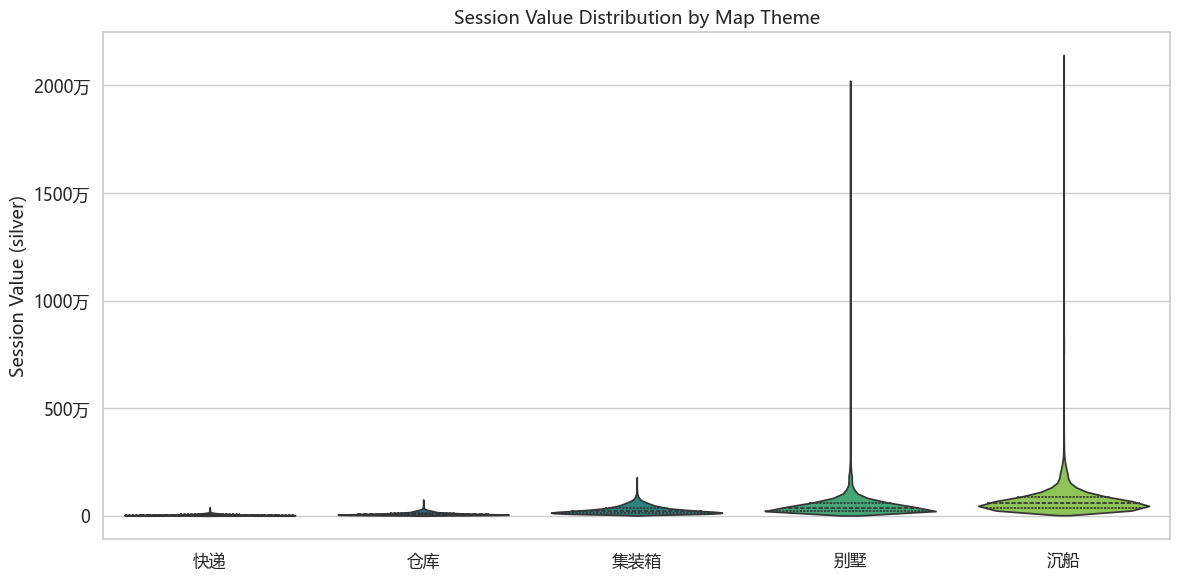

In [3]:
import pandas as pd

df = pd.DataFrame(records)

theme_order = ["快递", "仓库", "集装箱", "别墅", "沉船"]
palette = sns.color_palette("viridis", n_colors=len(theme_order))

fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(
    data=df, x="theme", y="value", order=theme_order,
    palette=palette, inner="quart", cut=0, ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("Session Value (silver)")
ax.set_title("Session Value Distribution by Map Theme")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e4:.0f}万" if x >= 1e4 else f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(str(ROOT / "notebooks" / "fig_session_value_by_theme.png"), dpi=150)
plt.show()

## 3. Tier comparison within each theme

C:\Users\shenc\AppData\Local\Temp\ipykernel_30992\1742023275.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\shenc\AppData\Local\Temp\ipykernel_30992\1742023275.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\shenc\AppData\Local\Temp\ipykernel_30992\1742023275.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\shenc\AppData\Local\Temp\ipykernel_30992\1742023275.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

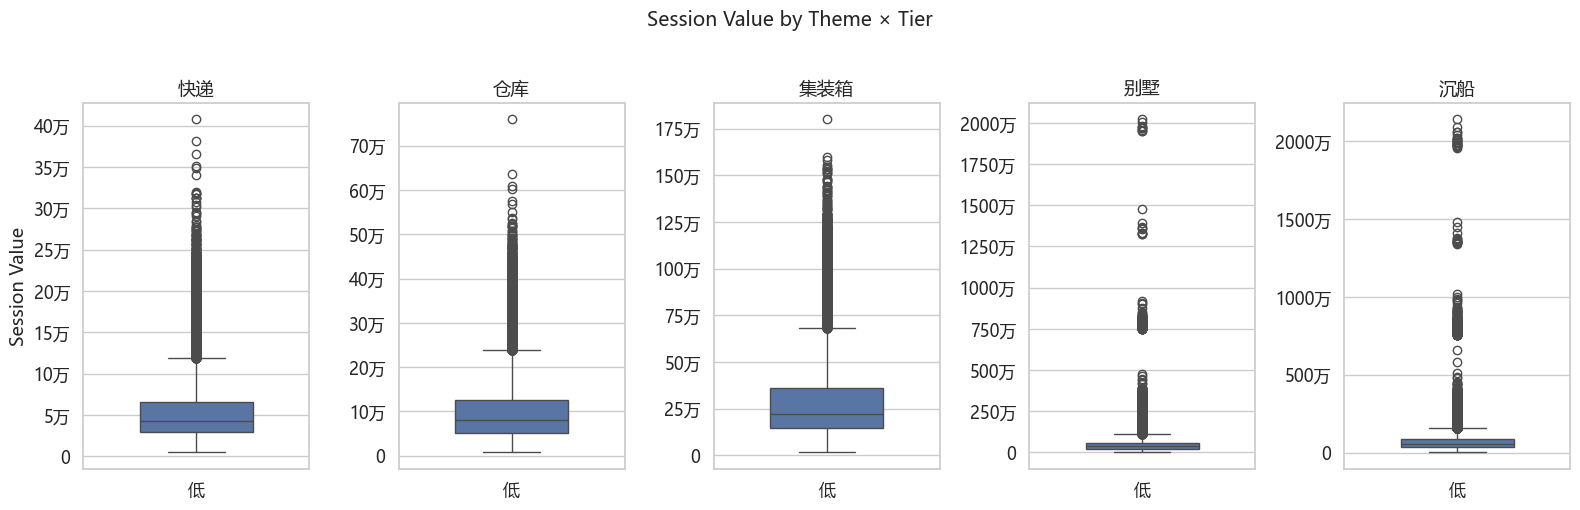

In [4]:
tier_order = ["低", "中", "高"]
tier_palette = {"低": "#4c72b0", "中": "#dd8452", "高": "#c44e52"}

summary = (
    df.groupby(["theme", "tier"])["value"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

fig, axes = plt.subplots(1, len(theme_order), figsize=(16, 5), sharey=False)
for ax, theme in zip(axes, theme_order):
    sub = df[df["theme"] == theme]
    available_tiers = [t for t in tier_order if t in sub["tier"].unique()]
    sns.boxplot(
        data=sub, x="tier", y="value", order=available_tiers,
        palette=tier_palette, width=0.5, ax=ax,
    )
    ax.set_title(theme)
    ax.set_xlabel("")
    ax.set_ylabel("" if ax != axes[0] else "Session Value")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e4:.0f}万" if x >= 1e4 else f"{x:,.0f}"))

fig.suptitle("Session Value by Theme × Tier", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(str(ROOT / "notebooks" / "fig_session_value_by_tier.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4. Summary table — mean, median, p5, p95 per theme

In [5]:
agg = (
    df.groupby("theme")["value"]
    .agg(
        mean="mean",
        median="median",
        p5=lambda x: np.percentile(x, 5),
        p95=lambda x: np.percentile(x, 95),
        std="std",
        cv=lambda x: x.std() / x.mean(),
    )
    .reindex(theme_order)
)
agg[["mean", "median", "p5", "p95", "std"]] = agg[["mean", "median", "p5", "p95", "std"]].round(0).astype(int)
agg["cv"] = agg["cv"].round(2)
agg

,mean,median,p5,p95,std,cv
theme,,,,,,
快递,52315,42452,17714,119552,33275,0.64
仓库,99889,80250,29658,239732,67561,0.68
集装箱,276040,224461,78846,639822,181333,0.66
别墅,477248,376892,111706,1126134,474053,0.99
沉船,705735,583464,184497,1600819,642996,0.91


## 5. Item quality mix per theme

What fraction of each theme's drop pool is white / green / blue / purple / gold / red?

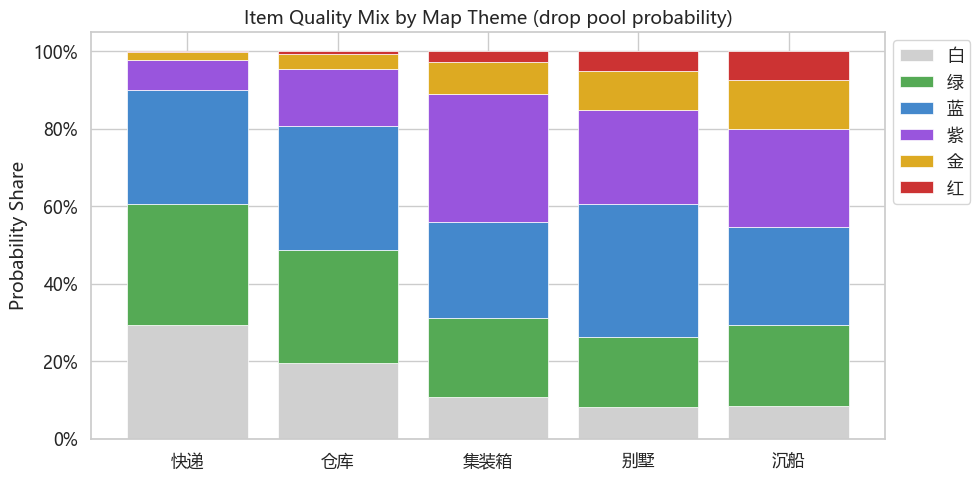

In [6]:
QUALITY_NAMES = {0: "无色", 1: "白", 2: "绿", 3: "蓝", 4: "紫", 5: "金", 6: "红"}
QUALITY_COLORS = {0: "#999999", 1: "#d0d0d0", 2: "#55aa55", 3: "#4488cc", 4: "#9955dd", 5: "#ddaa22", 6: "#cc3333"}

quality_rows = []
seen_pools = set()
for mid, m in sorted(leaf_maps.items()):
    theme_key = mid // 100
    if theme_key not in THEME_NAMES or m.drop_pool_id in seen_pools:
        continue
    seen_pools.add(m.drop_pool_id)

    fp = flatten_pool(m.drop_pool_id, drops, items)
    for iid, prob in zip(fp.item_ids, fp.probabilities):
        it = items[iid]
        quality_rows.append({
            "theme": THEME_NAMES[theme_key],
            "quality": it.quality,
            "prob": prob,
        })

qdf = pd.DataFrame(quality_rows)
qpivot = qdf.groupby(["theme", "quality"])["prob"].sum().unstack(fill_value=0)
qpivot = qpivot.div(qpivot.sum(axis=1), axis=0)
qpivot = qpivot.reindex(theme_order)

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(theme_order))
for q in sorted(qpivot.columns):
    vals = qpivot[q].values
    ax.bar(
        theme_order, vals, bottom=bottom,
        color=QUALITY_COLORS.get(q, "#666"),
        label=QUALITY_NAMES.get(q, str(q)),
        edgecolor="white", linewidth=0.5,
    )
    bottom += vals

ax.set_ylabel("Probability Share")
ax.set_title("Item Quality Mix by Map Theme (drop pool probability)")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig(str(ROOT / "notebooks" / "fig_quality_mix.png"), dpi=150, bbox_inches="tight")
plt.show()

## Takeaways

1. **沉船 >> 别墅 >> 集装箱 >> 仓库 >> 快递** in expected session value.
2. Same theme across tiers shares the drop pool — economic params (entry fee, budget) differ, not item distribution.
3. Higher-tier themes have wider value variance (CV), reflecting higher concentration of rare items.
4. Quality mix shifts toward purple/gold/red as themes get more expensive.